In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# Define State
class State(TypedDict):
    name: str
    response: str

In [4]:
# Define Nodes

def remember_name(state: State):
    return {
        "name": "Aman",
    }
    
def reply(state: State):
   return {
       "response": f"Hello {state['name']}! Nice to meet you."
   }
   

In [5]:
# Create Graph
builder = StateGraph(State)

builder.add_node("remember_name", remember_name)
builder.add_node("reply", reply)

builder.add_edge(START, "remember_name")
builder.add_edge("remember_name", "reply")
builder.add_edge("reply", END)

graph = builder.compile()

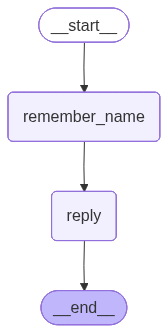

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Now Adding Simple Memory to it with threading

In [21]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from typing import TypedDict

In [22]:
#Define State
class State(TypedDict):
    name: str
    response: str

In [23]:
# Create Nodes
def remember_name(state: State):
    if state.get("name"):
        return {}
    return {
        "name": "Aman"
        }
    
def reply(state: State):
    return {
        "response": f"Hello {state['name']}! Nice to meet you."
    }

    

In [24]:
# Memory
memory = MemorySaver()

In [25]:
# Build Graph
builder = StateGraph(State)
builder.add_node("remember_name", remember_name)
builder.add_node("reply", reply)

builder.add_edge(START, "remember_name")
builder.add_edge("remember_name", "reply")
builder.add_edge("reply", END)

graph = builder.compile(checkpointer=memory)

In [26]:
# Create Thread Configuration

thread_id = "user_001"
config = {
    "configurable":{
        "thread_id": thread_id
    }
}

In [27]:
result1 = graph.invoke(
    {},
    config=config
)

In [28]:
result1

{'name': 'Aman', 'response': 'Hello Aman! Nice to meet you.'}

In [29]:
result2 = graph.invoke(
    {"name": "Karan"},
    config=config
)

In [30]:
result2

{'name': 'Karan', 'response': 'Hello Karan! Nice to meet you.'}

In [31]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'name': 'Karan', 'response': 'Hello Karan! Nice to meet you.'}, next=(), config={'configurable': {'thread_id': 'user_001', 'checkpoint_ns': '', 'checkpoint_id': '1f1658c7-0036-606a-8006-3b9d78891f4d'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-06-11T11:55:27.429216+00:00', parent_config={'configurable': {'thread_id': 'user_001', 'checkpoint_ns': '', 'checkpoint_id': '1f1658c7-0034-6aa8-8005-e058e27e86c3'}}, tasks=(), interrupts=())

In [32]:
snapshot.values

{'name': 'Karan', 'response': 'Hello Karan! Nice to meet you.'}